# Compressive Sensing in MR
In this notebook, you'll see how it will be possible to reconstruct an MR from very strongly undersampled data.
The key, again, will be to find a representation in which the data are sparse. <br>
We suggest using **wavelets**: read a summary about them on Wiki <br>


# Wavelets: some examples

(-0.5, 239.5, 239.5, -0.5)

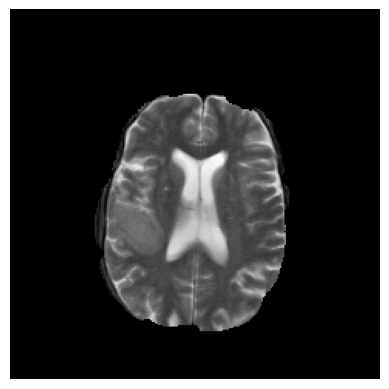

In [2]:
import numpy as np
import matplotlib.pyplot as plt
refImm = np.load('testMR.npy')
plt.imshow(refImm,cmap='gray')
# Reference full k-space of the reference image
kSpace = np.fft.fft2(refImm)
plt.axis('off')

In [3]:
import pywt
coeffs = pywt.wavedec2(refImm, wavelet='db4', level=3)

In [4]:
import matplotlib.pyplot as plt

def plot_wavedec2_coeffs(coeffs, cmap='gray'):
    """
    coeffs: output of pywt.wavedec2(image, wavelet, level=N)
    """
    cA = coeffs[0]
    details = coeffs[1:]  # list of (cH, cV, cD)

    n_levels = len(details)

    fig, axes = plt.subplots(n_levels + 1, 4, figsize=(12, 3*(n_levels+1)))
    
    # First row: approximation
    axes[0, 0].imshow(cA, cmap=cmap)
    axes[0, 0].set_title("Approximation A")
    axes[0, 1].axis("off")
    axes[0, 2].axis("off")
    axes[0, 3].axis("off")

    # Detail rows
    for i, (cH, cV, cD) in enumerate(details, start=1):
        level = n_levels - i + 1  # highest level first
        cm = cH.mean()-1.5*cH.std()
        cM = cH.mean()+1.5*cH.std()
        axes[i, 0].imshow(cH, cmap=cmap,vmin=cm,vmax=cM)
        axes[i, 0].set_title(f"Level {level} – Horizontal H")
        cm = cH.mean()-1.5*cV.std()
        cM = cH.mean()+1.5*cV.std()
        axes[i, 1].imshow(cV, cmap=cmap,vmin=cm,vmax=cM)
        axes[i, 1].set_title(f"Level {level} – Vertical V")
        cm = cD.mean()-1.5*cV.std()
        cM = cD.mean()+1.5*cV.std()
        axes[i, 2].imshow(cD, cmap=cmap,vmin=cm,vmax=cM)
        axes[i, 2].set_title(f"Level {level} – Diagonal D")

        axes[i, 3].axis("off")

    for axrow in axes:
        for ax in axrow:
            ax.set_xticks([])
            ax.set_yticks([])

    plt.tight_layout()
    plt.show()


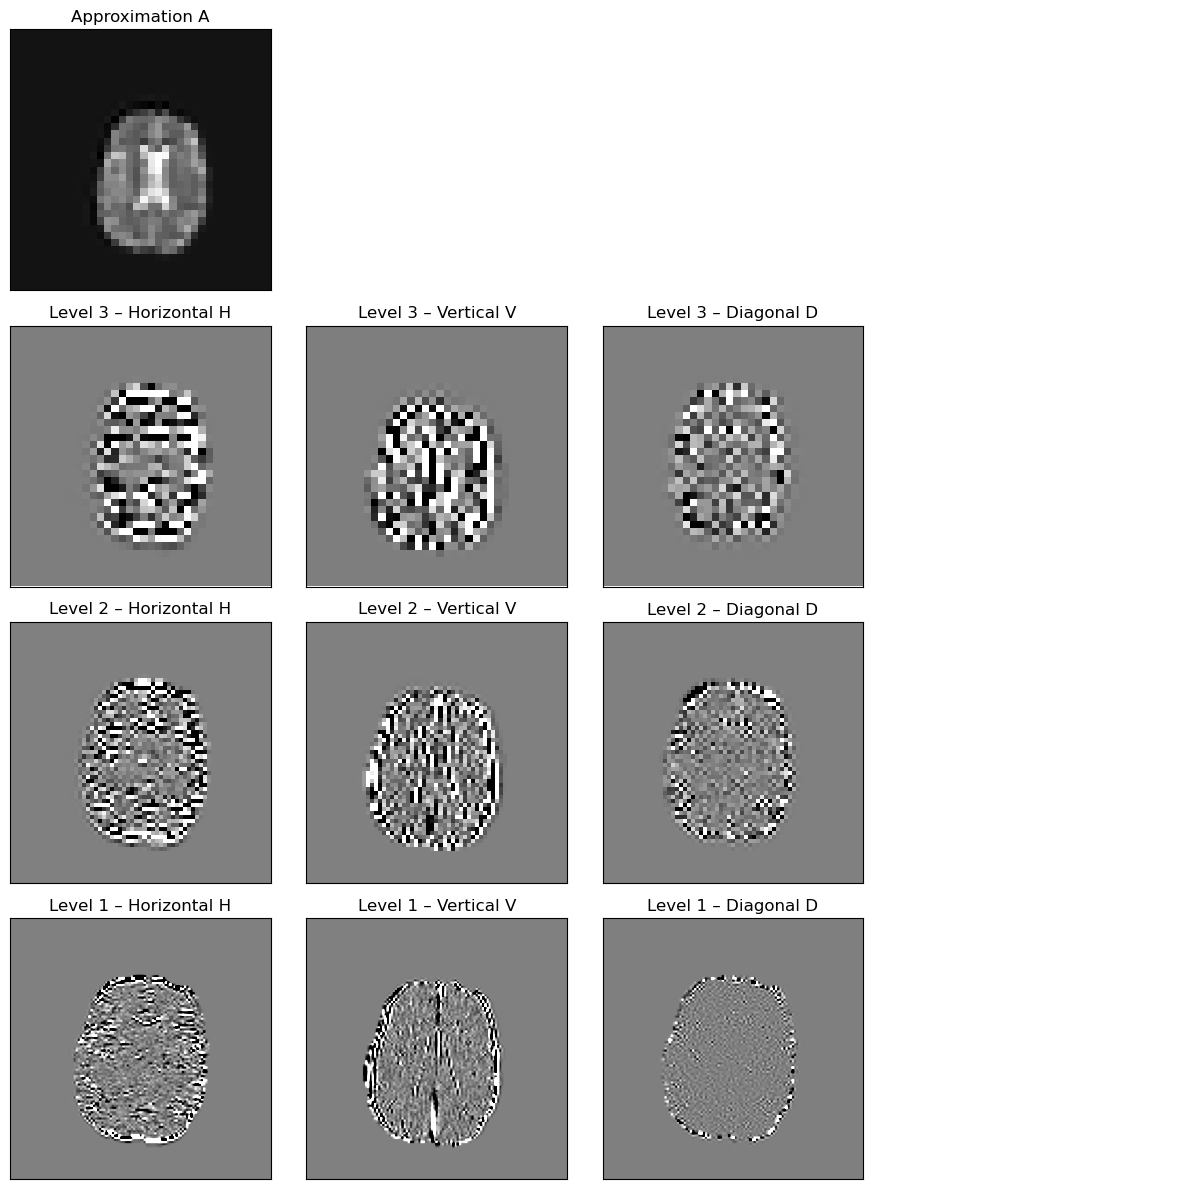

In [5]:

plot_wavedec2_coeffs(coeffs)


In [6]:
noisyImm = refImm + np.random.normal(0,.03,refImm.shape)
coeffs = pywt.wavedec2(noisyImm, wavelet='db4', level=3)

(150.0, 50.0)

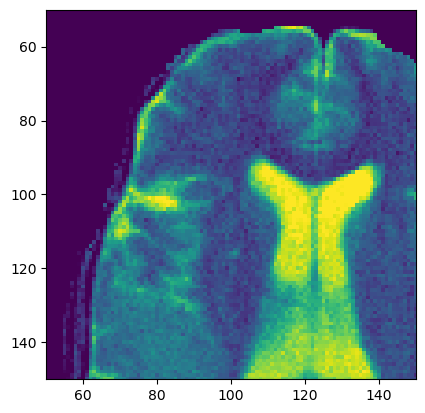

In [7]:
plt.imshow(noisyImm,vmin=.1,vmax=.9)
plt.xlim(50,150)
plt.ylim(150,50)

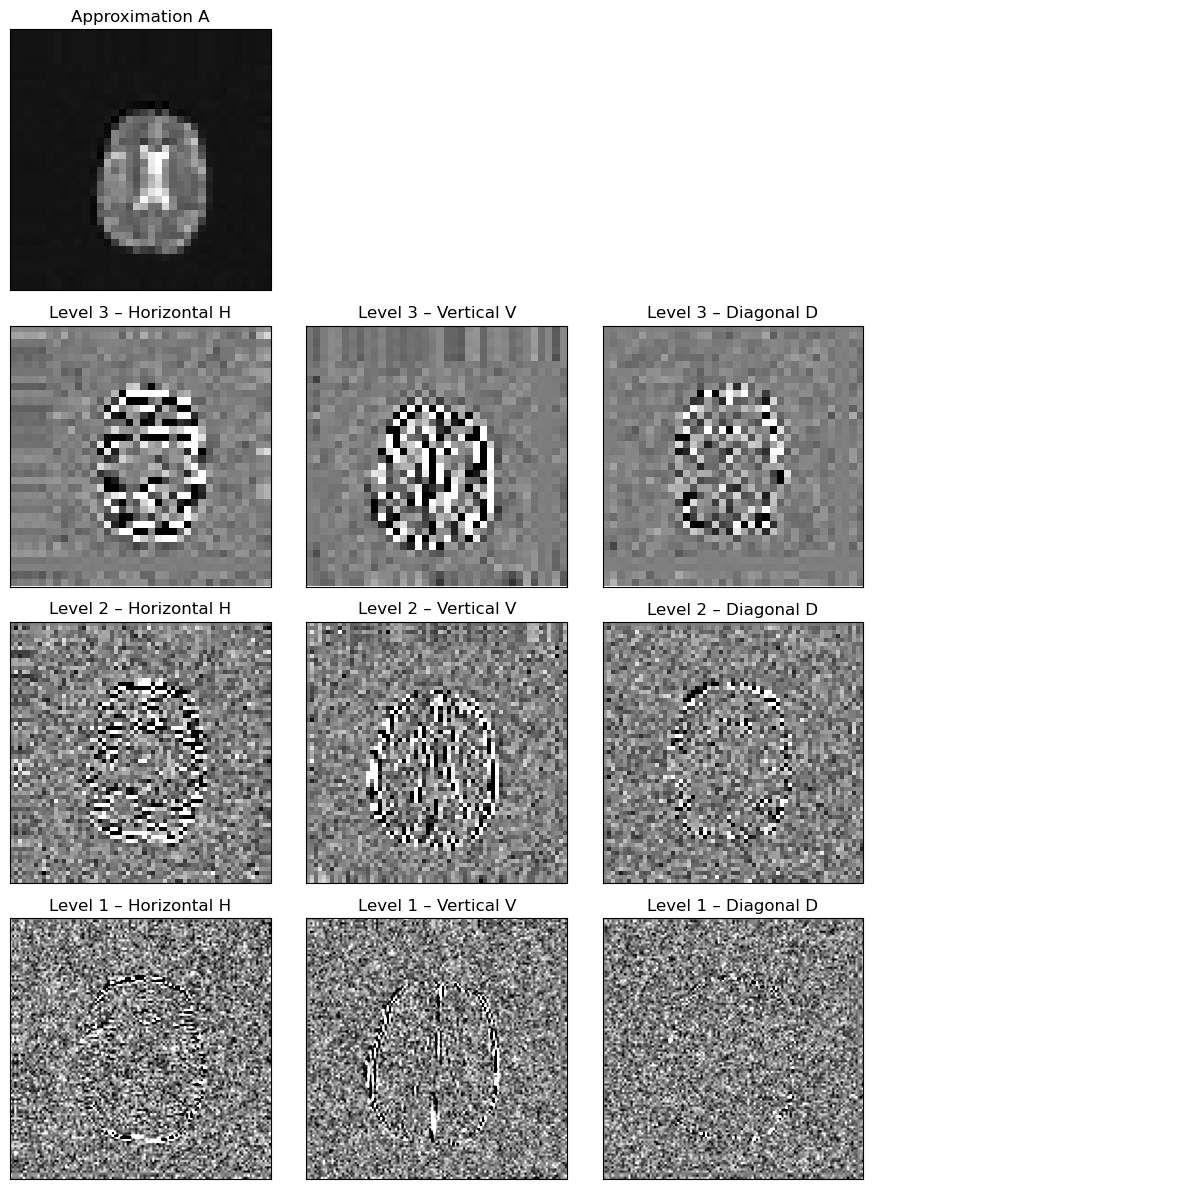

In [8]:
plot_wavedec2_coeffs(coeffs)


### k-space subsampling function

In [9]:
def fwdOp (x__):
    return np.fft.fft2(x__, norm='ortho')
def bkwdOp (x__):
    # make sure the output is real (it might not be due to some numerical rounding effects)
    return np.fft.ifft2(x__, norm='ortho').real

In [10]:
def lineWeightedSubSampling (x__, sampling_frac, noiseL = 0):
    data__ = fwdOp(x__)
    fv = np.fft.fftfreq(data__.shape[0])
    samplingPr = np.exp(-np.abs(fv)/(.5*sampling_frac))
    maskPr = np.random.uniform(0,1,size=data__.shape[0]) < samplingPr
    maskPr[:9] = True
    maskPr[-8:] = True    
    maskPr = np.expand_dims(maskPr, axis=1)
    data__ = data__ * maskPr
    data__ += np.random.normal(0, noiseL, size=data__.shape)
    print(f"Sampling fraction: {maskPr.sum()/maskPr.size:.1%}")
    return data__,maskPr

## Noise induced by random subsampling is not sparse in wavelet transform!

In [162]:
dataS,maskS = lineWeightedSubSampling(refImm,sampling_frac=.12)
invRec = np.fft.ifft2(dataS,norm='ortho').real

Sampling fraction: 16.7%


(-0.5, 239.5, 239.5, -0.5)

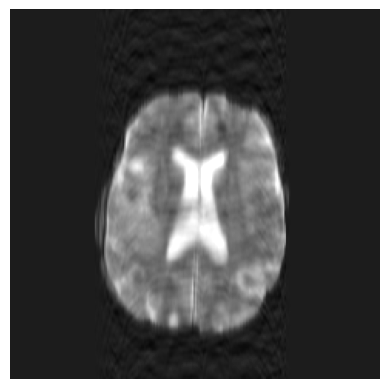

In [164]:
plt.imshow(invRec,cmap='gray',vmin=-.1,vmax=.8)
plt.axis('off')

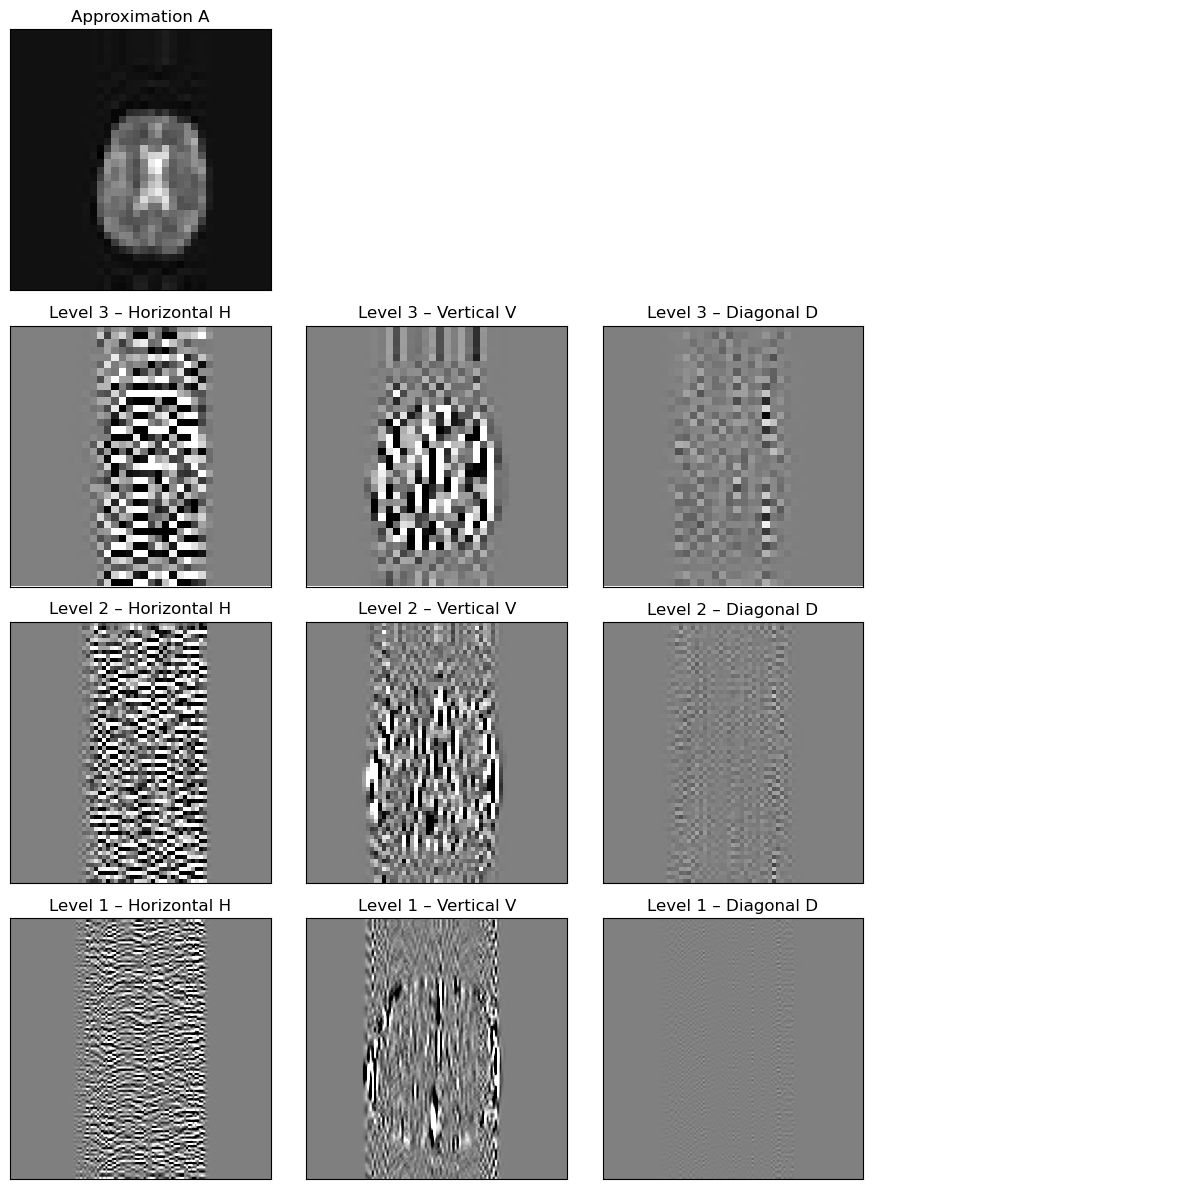

In [12]:
coeffs = pywt.wavedec2(invRec, wavelet='db4', level=3)
plot_wavedec2_coeffs(coeffs)

# Implement ISTA using wavelets
ISTA works like this:
1. Image gradient: current image estimate + $\alpha$ gradient ($F^{-1} M[Fx-y]$)
2. Soft thresholding: image -> wavelet transform -> soft thresholding -> anti-transform

In Math:
* Take some $x^0$, define the residual $r= M\left[Fx^0 -y\right]$
* $g^{k+1} = F^-1  M\left[ Fx^k -y\right]$
* $x^{k+0.5} = x^k -\tau g$
* $ w = Wx^{k+0.5}$
* $ w = \operatorname{sign}(w)\,\max(|w|-\tau \beta,0)$
* $ x^{k+1} = W^{-1} w $


### L1 Wavelet regularized reconstruction
Application of the ISTA algorithm

In [13]:
def randomWeightedSubSampling (x__, sampling_frac, noiseL = 0):
    data__ = fwdOp(x__)
    print(data__.shape)
    fx = np.fft.fftfreq(data__.shape[0])
    fx = np.expand_dims(fx, axis=1)
    fy = np.fft.fftfreq(data__.shape[1])
    fy = np.expand_dims(fy, axis=0)
    samplingPr = np.exp(-np.sqrt(fx**2+fy**2)/sampling_frac)
    maskPr = np.random.uniform(0,1,size=data__.shape) < samplingPr
    maskPr[:15,:15] = True
    maskPr[-14:, -14:] = True
    maskPr[:15,-14:] = True
    maskPr[-14:,:15] = True    
    data__ = data__ * maskPr
    data__ += np.random.normal(0, noiseL, size=data__.shape)
    print(f"Sampling fraction: {maskPr.sum()/maskPr.size:.1%}")
    return data__,maskPr

In [14]:
def ISTArecon (i1__,mask__ = None, inImm__ = None, num_iters=100, beta_ =0.1,tau=.5):
    if inImm__ is not None:
        x = inImm__.copy()
    else:
        x = np.zeros_like(i1__).real
    if mask__ is None:
        mask__ = 1
    lossV = np.zeros((num_iters,3))
    # Save in Loss [:,0] the data fideilty term
    # in loss [:,1] $\beta |w|$
    # in loss [:,2] the number of non-zero coefficients
    for itIdx in range(num_iters):
        resFS = mask__ * (fwdOp(x)-i1__) # The gradient in sinogram space
        lossV[itIdx,0] = np.linalg.norm(resFS)**2 # Data fidelity term loss
        res = bkwdOp(resFS) # gradient in image space
        x -= tau*res # update the current image by \tau gradient
        coeffs = pywt.wavedec2(x, wavelet='db4', level=3) # decompes the image in wavelet space
        coeffs = list(coeffs) # Shrink the wavelets by beta tau
        for i in range(1,len(coeffs)):
            cH, cV, cD = coeffs[i]
            coeffs[i] = (np.maximum(np.abs(cH)-tau*beta_,0)*np.sign(cH), # max (coeff - tau*beta,0) * sign (coeff)
                        np.maximum(np.abs(cV)-tau*beta_,0)*np.sign(cV),
                        np.maximum(np.abs(cD)-tau*beta_,0)*np.sign(cD))
        lossV[itIdx,1] = beta_*sum([np.abs(cH).sum() + np.abs(cV).sum() + np.abs(cD).sum() for cH,cV,cD in coeffs[1:]])
        lossV[itIdx,2] = sum([(np.abs(cH)>1e-10).sum() + (np.abs(cV)>1e-10).sum() + (np.abs(cD)>1e-10).sum() for cH,cV,cD in coeffs[1:]])
        x = pywt.waverec2(coeffs, wavelet='db4') # reconstruct the image
    return x,lossV

In [15]:
# Terms related to the spatial regularization
def spatGrad (x__):
    x_grad = np.diff(x__, axis=0, append=0)
    y_grad = np.diff(x__, axis=1, append=0)
    return x_grad,y_grad
def spatAdj (x_grad__, y_grad__):
    x_adj = np.diff(x_grad__, axis=0, prepend=0)
    y_adj = np.diff(y_grad__, axis=1, prepend=0)
    return x_adj + y_adj
def iterReconMR (i1__,mask__ = None, inImm__ = None, num_iters=100, beta_ =0.1):
    if inImm__ is not None:
        x = inImm__.copy()
    else:
        x = np.zeros_like(i1__).real
    if mask__ is None:
        mask__ = 1
    res = (fwdOp(x) - i1__)
    lossV = np.zeros((num_iters,2))
    for i in range(num_iters):
        # Compute the gradient of the data fidelity term. Note the mask!
        grad_data = bkwdOp(res * mask__)
        # Compute the gradient of the regularization term
        x_grad, y_grad = spatGrad(x)
        grad_reg = spatAdj(x_grad, y_grad)
        # full grad
        grad = grad_data - beta_ * grad_reg
        # Compute the step size (using the exact equation)
        num = np.sum(grad**2)
        grad_fwd = fwdOp(grad)
        gx,gy = spatGrad(grad)
        den = np.sum(np.abs(mask__*grad_fwd)**2) + beta_ * np.sum(gx**2 + gy**2)
        alpha = num / den
        # update the image
        x = x - alpha * grad
        res = res - alpha * grad_fwd
        # Compute the loss
        lossV[i,0] = np.linalg.norm(mask__*res)**2
        lossV[i,1] = np.linalg.norm(grad_reg)**2
    return x,lossV    

## Test the effectiveness of the model with L1 regularization


In [16]:
betaL = [1e-3 ,2e-3,0.005,0.01,0.03 ,0.1,0.2]
recV = []
rmseV = []
lossV = []
nnzV = []
subValL = [0.1,0.2 ,0.3,0.4]
rmse_L2 = []
lossV_L2 = []
for alpha in subValL:
    #data1,mask1 = lineWeightedSubSampling(refImm,sampling_frac=alpha, noiseL=0.0)
    data1,mask1 = randomWeightedSubSampling(refImm,sampling_frac=alpha,noiseL=0.0)
    for beta in betaL:
        recImm,los= ISTArecon(data1, mask__=mask1, num_iters=400, beta_=beta)
        recV.append(recImm)
        rmse = np.sqrt(np.mean((recImm - refImm)**2))
        rmseV.append(rmse)
        lossV.append(los[-1,0])
        nnzV.append(los[-1,2])
        recImm2,los = iterReconMR(data1,mask__=mask1,num_iters=200,beta_=beta)
        lossV_L2.append(los[-1,0])
        rmse_L2.append(np.sqrt(np.mean((recImm2-refImm)**2)))

(240, 240)
Sampling fraction: 6.7%
(240, 240)
Sampling fraction: 19.3%
(240, 240)
Sampling fraction: 31.6%
(240, 240)
Sampling fraction: 41.0%


Text(0.5, 0, '$\\beta$')

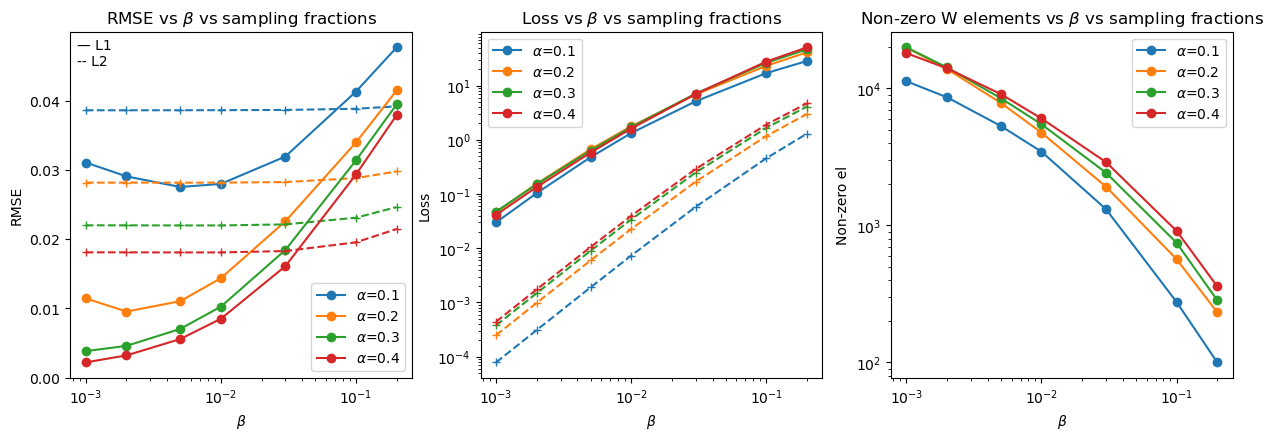

In [36]:
lossV = np.array(lossV).reshape(len(subValL), len(betaL))
rmseV = np.array(rmseV).reshape(len(subValL), len(betaL))
rmseL2 = np.array(rmse_L2).reshape(len(subValL), len(betaL))
lossV_L2 = np.array(lossV_L2).reshape(len(subValL), len(betaL))
nnzV = np.array(nnzV).reshape(len(subValL),len(betaL))
plt.figure(figsize=(15,4.5))
plt.subplot(131)
# Define the colors we want to use
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
leg = [rf'$\alpha$={alpha}' for alpha in subValL]
for i in range(rmseV.shape[0]):  # Loop over each column of rmseV
    plt.plot(betaL, rmseV[i], color=colors[i%len(colors)], marker='o', linestyle='-',label=leg[i])
    plt.plot(betaL, rmseL2[i], color=colors[i%len(colors)], marker='+', linestyle='--')
plt.legend()
plt.annotate("— L1\n-- L2", xy=(0.02, 0.98), xycoords='axes fraction',
             va='top', fontsize=10)

plt.xscale('log')
plt.title(r'RMSE vs $\beta$ vs sampling fractions')
plt.ylabel('RMSE')
plt.xlabel(r'$\beta$')

# Loss
plt.subplot(132)
for i in range(lossV.shape[0]):  # Loop over each column of lossV
    plt.plot(betaL, lossV[i], color=colors[i%len(colors)], marker='o', linestyle='-',label=leg[i])
    plt.plot(betaL, lossV_L2[i], color=colors[i%len(colors)], marker='+', linestyle='--')
plt.legend()
plt.xscale('log')
#plt.xlim(4e-3,1e-1)
plt.title(r'Loss vs $\beta$ vs sampling fractions')
plt.ylabel('Loss')
plt.yscale('log')
plt.xlabel(r'$\beta$')

# Non-zero el
plt.subplot(133)
for i in range(nnzV.shape[0]):  # Loop over each column of nnzV
    plt.plot(betaL, nnzV[i], color=colors[i%len(colors)], marker='o', linestyle='-')
plt.legend(leg)
plt.xscale('log')
#plt.xlim(4e-3,1e-1)
plt.title(r'Non-zero W elements vs $\beta$ vs sampling fractions')
plt.ylabel('Non-zero el')
plt.yscale('log')
plt.xlabel(r'$\beta$')

### Different subsampling, best RMSE along $\beta$

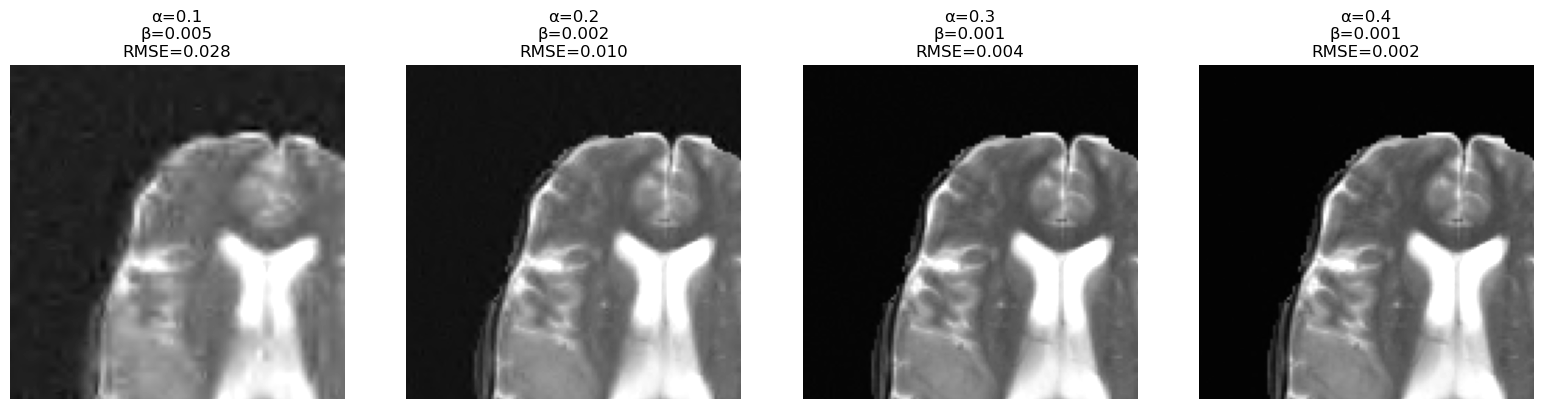

In [37]:
recV = np.array(recV)
recM = recV.reshape(len(subValL), len(betaL), 240, 240)
fig, axs = plt.subplots(1, len(subValL), figsize=(4*len(subValL), 4))
for i, alpha in enumerate(subValL):
    j_best = np.argmin(rmseV[i])
    axs[i].imshow(recM[i, j_best,:,:], cmap='gray',vmax=.8) #,vmin=0.1, vmax=0.9)
    axs[i].set_xlim(30,150)
    axs[i].set_ylim(150,30)
    axs[i].set_title(f"α={alpha}\nβ={betaL[j_best]}\nRMSE={rmseV[i,j_best]:.3f}")
    axs[i].axis('off')

plt.tight_layout()
plt.show()

### $\alpha=20\%$, effect of varying $\beta$

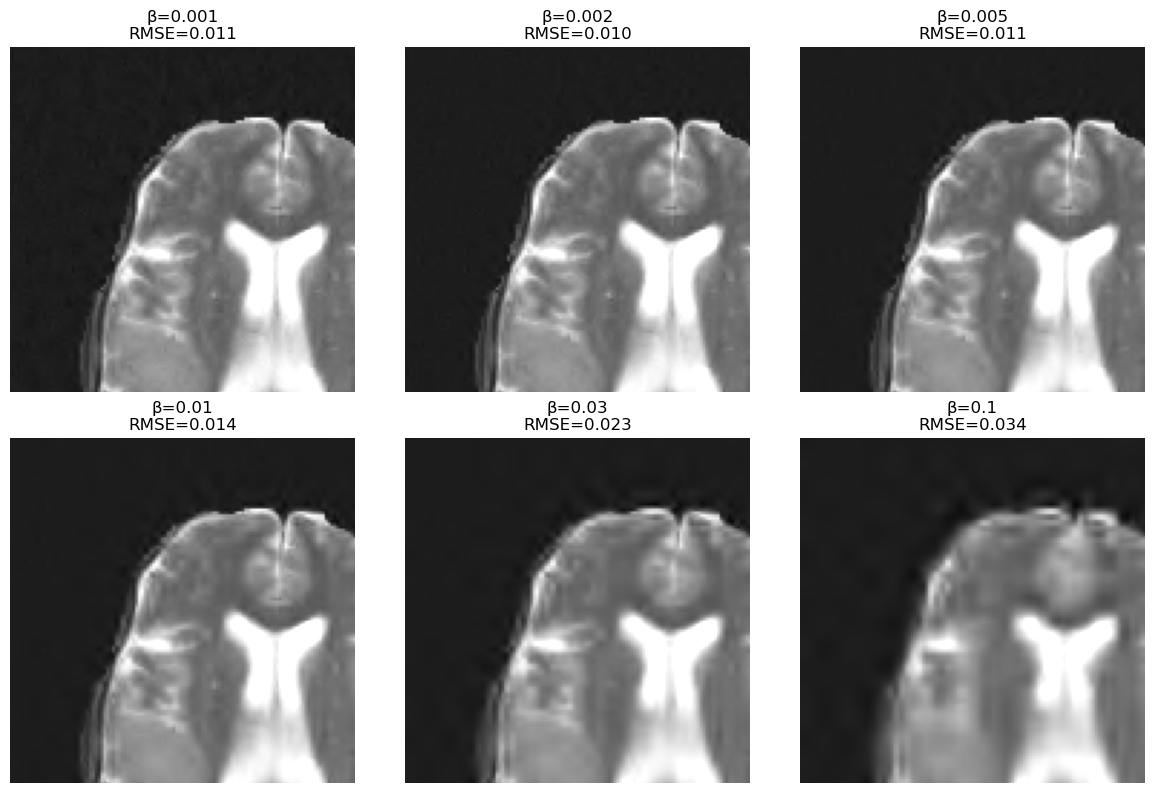

In [38]:
rows = 2
cols = 3   # last cell unused

fig, axs = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
axs = axs.flatten()

for i, beta in enumerate(betaL[:]):
    axs[i].imshow(recM[1, i], cmap='gray', vmin=-0.1, vmax=0.8)
    axs[i].set_xlim(30,150)
    axs[i].set_ylim(150,30)
    axs[i].set_title(f"β={beta}\nRMSE={rmseV[1,i]:.3f}")
    axs[i].axis('off')
    if (i>4):
        break



plt.tight_layout()
plt.show()


# Compare line subsampling with random subsampling

In [39]:
betaL = [1e-3, 2e-3, 0.005, 0.01, 0.03, 0.1, 0.2]
recV_line = []
rmseV_line = []
lossV_line = []
nnzV_line = []
subValL = [0.1, 0.2, 0.3, 0.4]
for alpha in subValL:
    data1, mask1 = lineWeightedSubSampling(refImm, sampling_frac=alpha, noiseL=0.0)
    for beta in betaL:
        recImm, los = ISTArecon(data1, mask__=mask1, num_iters=400, beta_=beta)
        recV_line.append(recImm)
        rmse = np.sqrt(np.mean((recImm - refImm)**2))
        rmseV_line.append(rmse)
        lossV_line.append(los[-1,0])
        nnzV_line.append(los[-1,2])


Sampling fraction: 12.1%
Sampling fraction: 23.3%
Sampling fraction: 30.8%
Sampling fraction: 39.2%


Text(0.5, 0, '$\\beta$')

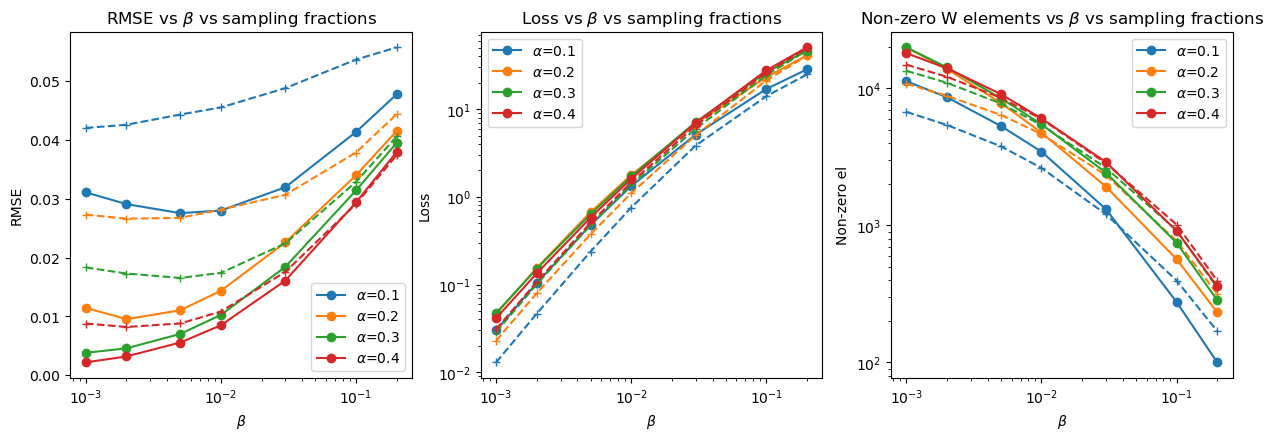

In [40]:
lossV_line = np.array(lossV_line).reshape(len(subValL), len(betaL))
rmseV_line = np.array(rmseV_line).reshape(len(subValL), len(betaL))
nnzV_line = np.array(nnzV_line).reshape(len(subValL),len(betaL))
plt.figure(figsize=(15,4.5))
plt.subplot(131)
# Define the colors we want to use
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
leg = [rf'$\alpha$={alpha}' for alpha in subValL]
for i in range(rmseV.shape[0]):  # Loop over each column of rmseV
    plt.plot(betaL, rmseV[i], color=colors[i%len(colors)], marker='o', linestyle='-',label=leg[i])
    plt.plot(betaL, rmseV_line[i], color=colors[i%len(colors)], marker='+', linestyle='--')
plt.legend()
plt.xscale('log')
plt.title(r'RMSE vs $\beta$ vs sampling fractions')
plt.ylabel('RMSE')
plt.xlabel(r'$\beta$')

# Loss
plt.subplot(132)
for i in range(lossV.shape[0]):  # Loop over each column of lossV
    plt.plot(betaL, lossV[i], color=colors[i%len(colors)], marker='o', linestyle='-',label=leg[i])
    plt.plot(betaL, lossV_line[i], color=colors[i%len(colors)], marker='+', linestyle='--')
plt.legend()
plt.xscale('log')
#plt.xlim(4e-3,1e-1)
plt.title(r'Loss vs $\beta$ vs sampling fractions')
plt.ylabel('Loss')
plt.yscale('log')
plt.xlabel(r'$\beta$')

# Non-zero el
plt.subplot(133)
for i in range(nnzV.shape[0]):  # Loop over each column of nnzV
    plt.plot(betaL, nnzV[i], color=colors[i%len(colors)], marker='o', linestyle='-',label=leg[i])
    plt.plot(betaL, nnzV_line[i], color=colors[i%len(colors)], marker='+', linestyle='--')
plt.legend()
plt.xscale('log')
#plt.xlim(4e-3,1e-1)
plt.title(r'Non-zero W elements vs $\beta$ vs sampling fractions')
plt.ylabel('Non-zero el')
plt.yscale('log')
plt.xlabel(r'$\beta$')

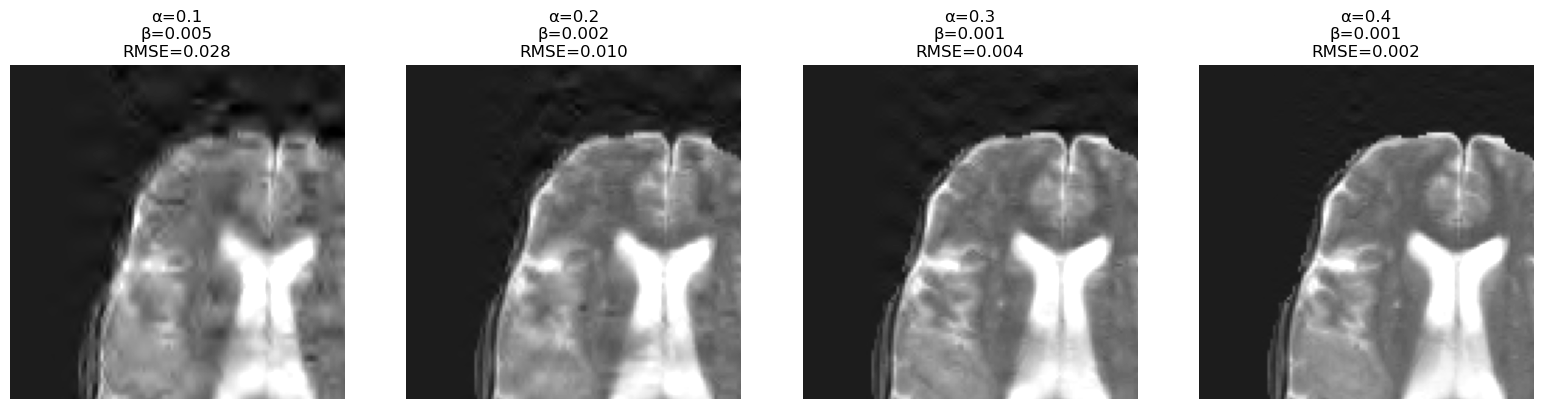

In [41]:
recV_line = np.array(recV_line)
recM_line = recV_line.reshape(len(subValL), len(betaL), 240, 240)
fig, axs = plt.subplots(1, len(subValL), figsize=(4*len(subValL), 4))
for i, alpha in enumerate(subValL):
    j_best = np.argmin(rmseV[i])
    axs[i].imshow(recM_line[i, j_best,:,:], cmap='gray',vmin=-.1,vmax=.8) #,vmin=0.1, vmax=0.9)
    axs[i].set_xlim(30,150)
    axs[i].set_ylim(150,30)
    axs[i].set_title(f"α={alpha}\nβ={betaL[j_best]}\nRMSE={rmseV[i,j_best]:.3f}")
    axs[i].axis('off')

plt.tight_layout()
plt.show()

# Denoising problem
Is denoising easier than reconstructing an undersampled image?



In [ ]:
betaL = [0.003,0.006,0.01,0.02,0.04 ,0.1,0.2]
recV_n = []
rmseV_n = []
lossV_n = []
subValL = [3]
for alpha in subValL:
    data,mask = lineWeightedSubSampling(refImm,sampling_frac=alpha, noiseL=0.03)
    for beta in betaL:
        recImm,los= ISTArecon(data, mask__=mask, num_iters=1000, beta_=beta)
        recV_n.append(recImm)
        rmse = np.sqrt(np.mean((recImm - refImm)**2))
        rmseV_n.append(rmse)
        lossV_n.append(los)

Sampling fraction: 81.7%


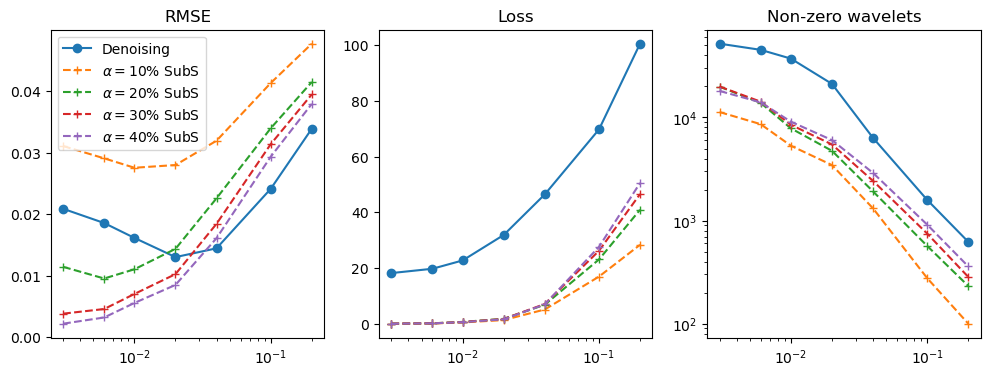

In [ ]:
lossV_n = np.array(lossV_n).reshape( len(betaL),-1, 3)
rmseV_n = np.array(rmseV_n).reshape(len(betaL), -1)
plt.figure(figsize=(12,4))
plt.subplot(131)
plt.plot(betaL,rmseV_n,'o-')
plt.plot(betaL,rmseV.T,'+--')
plt.legend(['Denoising']+[rf'$\alpha=${x:.0%} SubS' for x in [0.1,0.2,0.3,0.4]])
plt.xscale('log')
plt.title('RMSE')
plt.subplot(132)
plt.plot(betaL,lossV_n[:,-1,0],'o-')
plt.plot(betaL,lossV.T,'+--')
plt.title('Data Fidelity')
plt.xscale('log')
plt.subplot(133)
plt.plot(betaL,lossV_n[:,-1,2],'o-')
plt.plot(betaL,nnzV.T,'+--')
plt.yscale('log')
plt.title('Non-zero wavelets')
plt.xscale('log')

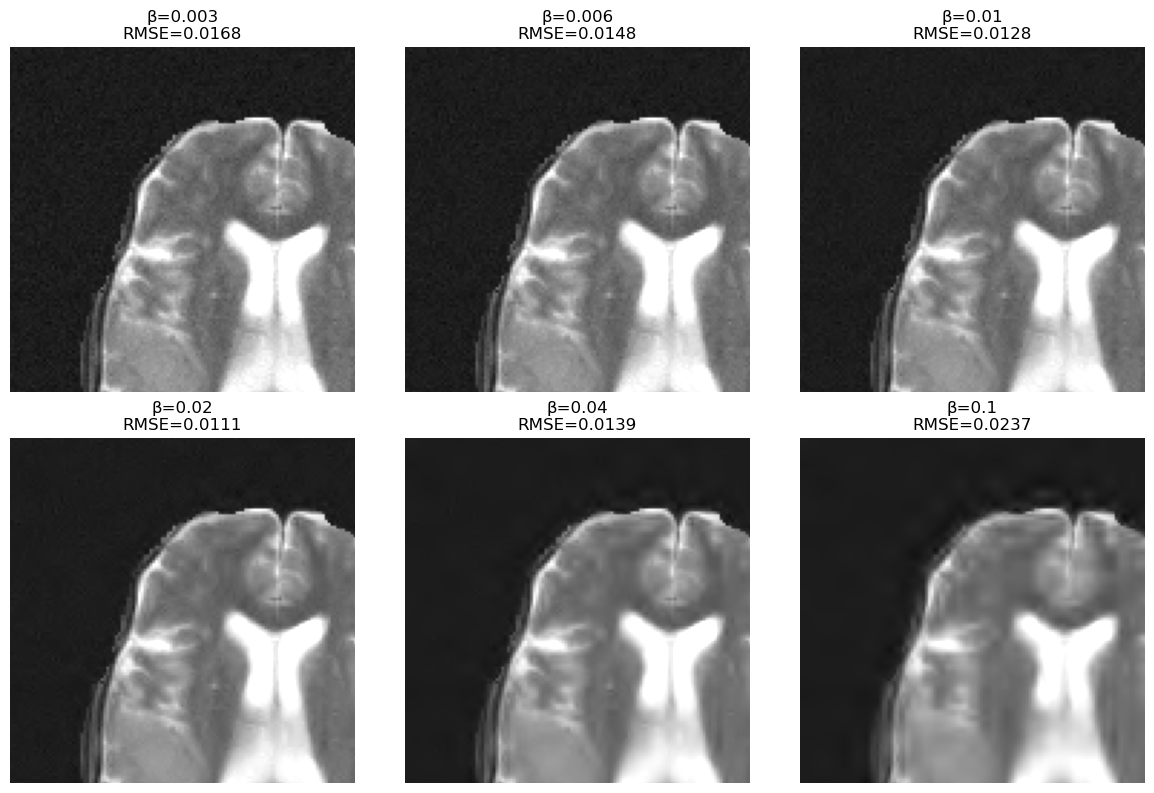

In [90]:
recV_n = np.array(recV_n)
recV_n = recV_n.reshape(len(subValL), len(betaL), 240, 240)
rows = 2
cols = 3   # last cell unused

fig, axs = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
axs = axs.flatten()

for i, beta in enumerate(betaL[:-1]):
    axs[i].imshow(recV_n[0, i,:,:], cmap='gray', vmin=-0.1, vmax=0.8)
    axs[i].set_xlim(30,150)
    axs[i].set_ylim(150,30)
    axs[i].set_title(f"β={beta}\nRMSE={rmseV_n[i,0]:.4f}")
    axs[i].axis('off')

# hide the unused 8th axis
axs[-1].axis('off')

plt.tight_layout()
plt.show()

# Compare with TV

In [125]:
def MR_TV_recon (inpImm_,ks_,cM_,beta_=1e-6,nIt_ = 300):

    recImm_ = np.zeros_like(inpImm_) #,dtype=np.float32)
    curKS = np.fft.fft2(recImm_,norm='ortho')
    curDual = np.zeros_like(ks_)
    recImmStar = recImm_.copy() #np.zeros_like(recImm)
    tvImm = np.zeros(inpImm_.shape+(2,)) #,dtype=np.float32)
    L = 1.+beta_*4 #((2e-12)+beta*4)
    L *= 2.
    sigma = 1/L
    tau = 1/(L)
    theta = 0.9
    loss_ = np.zeros((nIt_,3))
    for itIdx_ in range(nIt_):
        curDual = (curDual+sigma*(cM_*(curKS-ks_)))/(1+sigma)
        zTemp = np.zeros_like(tvImm)
        zTemp[:,:,0] = np.diff(recImm_,axis=0,prepend=0)
        zTemp[:,:,1] = np.diff(recImm_,axis=1,prepend=0)
        bP = np.fft.ifft2(curDual,norm='ortho').real
        gmImm = np.sqrt(np.sum((tvImm+sigma*zTemp)**2,axis=-1))
        gmImm = np.expand_dims(gmImm,axis=-1)
        tvImm = beta_*(tvImm+sigma*zTemp)/np.maximum(beta_,gmImm)
        bTV = np.diff(tvImm[:,:,0],axis=0,append=0)+np.diff(tvImm[:,:,1],axis=1,append=0)
        recImmOld = recImm_.copy()
        recImm_ = recImm_-tau*bP+tau*bTV
        recImmStar = recImm_+theta*(recImm_-recImmOld)
        curKS = np.fft.fft2(recImmStar,norm='ortho')
        loss_[itIdx_,0] = np.linalg.norm(curKS-ks_)**2
        loss_[itIdx_,1] = beta_*np.sum(np.abs(zTemp))
        dummyG = np.sqrt(zTemp[:,:,0]**2+zTemp[:,:,1]**2)
        loss_[itIdx_,2] = np.sum(dummyG>4e-4)


    return recImm_,loss_

In [155]:
betaL = [1e-3 ,2e-3,0.005,0.01,0.03 ,0.1,0.2]
recV = []
rmseV = []
lossV = []
nnzV = []
subValL = [0.1,0.2 ,0.3,0.4]
rmse_L2 = []
lossV_L2 = []
recV_TV = []
lossTV = []
rmseTV = []
nnzTV  = []
for alpha in subValL:
    data1,mask1 = lineWeightedSubSampling(refImm,sampling_frac=alpha, noiseL=0.0)
    #data1,mask1 = randomWeightedSubSampling(refImm,sampling_frac=alpha,noiseL=0.0)
    for beta in betaL:
        recImm,los= ISTArecon(data1, mask__=mask1, num_iters=400, beta_=beta)
        recV.append(recImm)
        rmse = np.sqrt(np.mean((recImm - refImm)**2))
        rmseV.append(rmse)
        lossV.append(los[-1,0])
        nnzV.append(los[-1,2])
        recImm2,los = iterReconMR(data1,mask__=mask1,num_iters=200,beta_=beta)
        lossV_L2.append(los[-1,0])
        rmse_L2.append(np.sqrt(np.mean((recImm2-refImm)**2)))
        recImmTV,losTV = MR_TV_recon(refImm,data1, mask1, nIt_=300, beta_=beta)
        recV_TV.append(recImmTV)
        rmseTV.append(np.sqrt(np.mean((recImmTV-refImm)**2)))
        lossTV.append(losTV[-1,0])
        nnzTV.append(losTV[-1,2])
    


Sampling fraction: 11.7%
Sampling fraction: 19.6%
Sampling fraction: 27.9%
Sampling fraction: 32.5%


Text(0.5, 0, '$\\beta$')

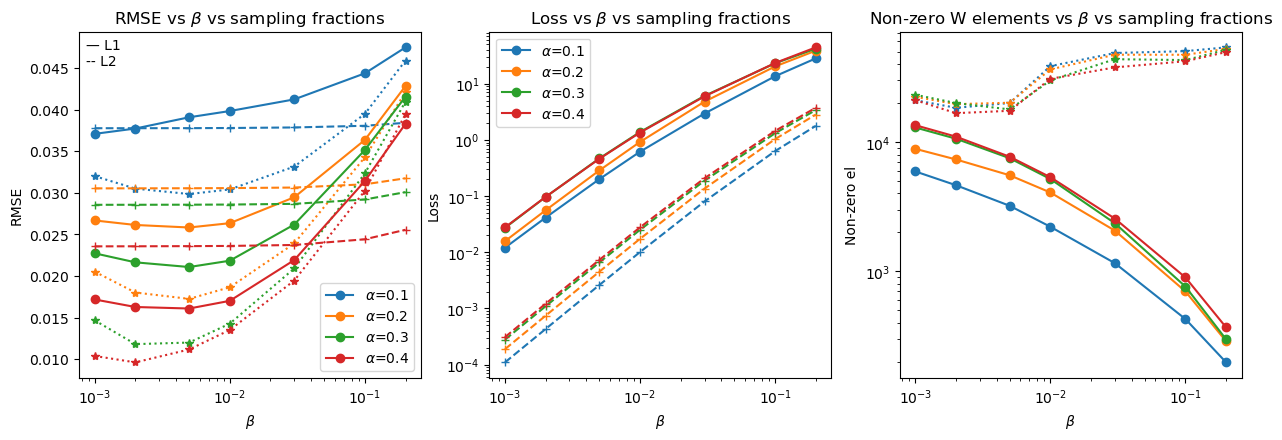

In [156]:
lossV = np.array(lossV).reshape(len(subValL), len(betaL))
rmseV = np.array(rmseV).reshape(len(subValL), len(betaL))
rmseL2 = np.array(rmse_L2).reshape(len(subValL), len(betaL))
lossV_L2 = np.array(lossV_L2).reshape(len(subValL), len(betaL))
nnzV = np.array(nnzV).reshape(len(subValL),len(betaL))

lossTV = np.array(lossTV).reshape(len(subValL), len(betaL))
rmseTV = np.array(rmseTV).reshape(len(subValL), len(betaL))
nnzTV = np.array(nnzTV).reshape(len(subValL),len(betaL))


plt.figure(figsize=(15,4.5))
plt.subplot(131)
# Define the colors we want to use
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
leg = [rf'$\alpha$={alpha}' for alpha in subValL]
for i in range(rmseV.shape[0]):  # Loop over each column of rmseV
    plt.plot(betaL, rmseV[i], color=colors[i%len(colors)], marker='o', linestyle='-',label=leg[i])
    plt.plot(betaL,rmseTV[i],color=colors[i%len(colors)],marker='*',linestyle=':')
    plt.plot(betaL, rmseL2[i], color=colors[i%len(colors)], marker='+', linestyle='--')
plt.legend()
plt.annotate("— L1\n-- L2", xy=(0.02, 0.98), xycoords='axes fraction',
             va='top', fontsize=10)

plt.xscale('log')
plt.title(r'RMSE vs $\beta$ vs sampling fractions')
plt.ylabel('RMSE')
plt.xlabel(r'$\beta$')

# Loss
plt.subplot(132)
for i in range(lossV.shape[0]):  # Loop over each column of lossV
    plt.plot(betaL, lossV[i], color=colors[i%len(colors)], marker='o', linestyle='-',label=leg[i])
    plt.plot(betaL, lossV_L2[i], color=colors[i%len(colors)], marker='+', linestyle='--')
plt.legend()
plt.xscale('log')
#plt.xlim(4e-3,1e-1)
plt.title(r'Loss vs $\beta$ vs sampling fractions')
plt.ylabel('Loss')
plt.yscale('log')
plt.xlabel(r'$\beta$')

# Non-zero el
plt.subplot(133)
for i in range(nnzV.shape[0]):  # Loop over each column of nnzV
    plt.plot(betaL, nnzV[i], color=colors[i%len(colors)], marker='o', linestyle='-')
    plt.plot(betaL,nnzTV[i], color=colors[i%len(colors)], marker='*', linestyle=':')

#plt.legend(leg)
plt.xscale('log')
#plt.xlim(4e-3,1e-1)
plt.title(r'Non-zero W elements vs $\beta$ vs sampling fractions')
plt.ylabel('Non-zero el')
plt.yscale('log')
plt.xlabel(r'$\beta$')

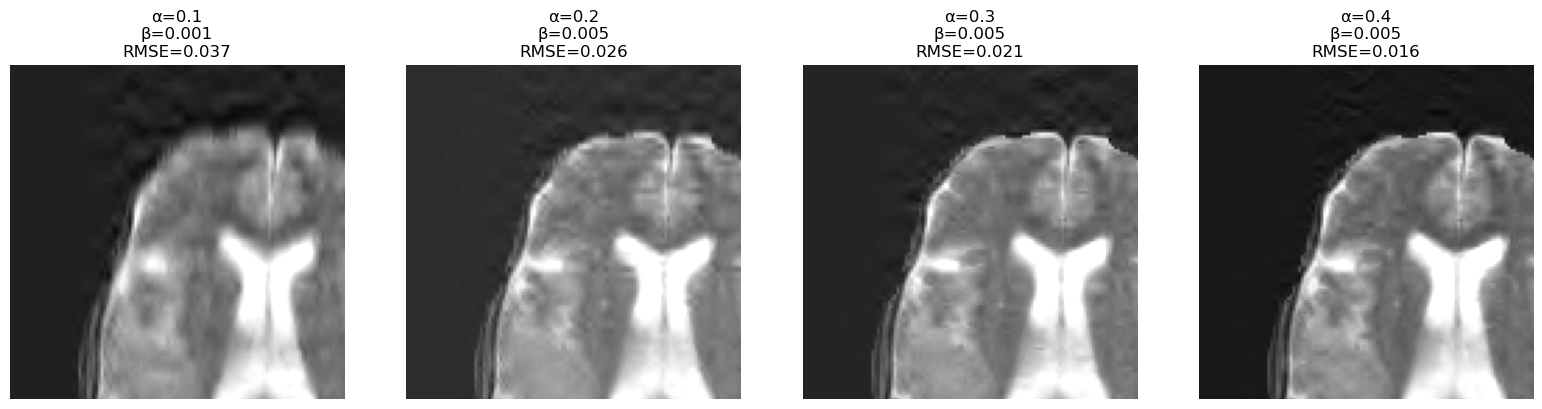

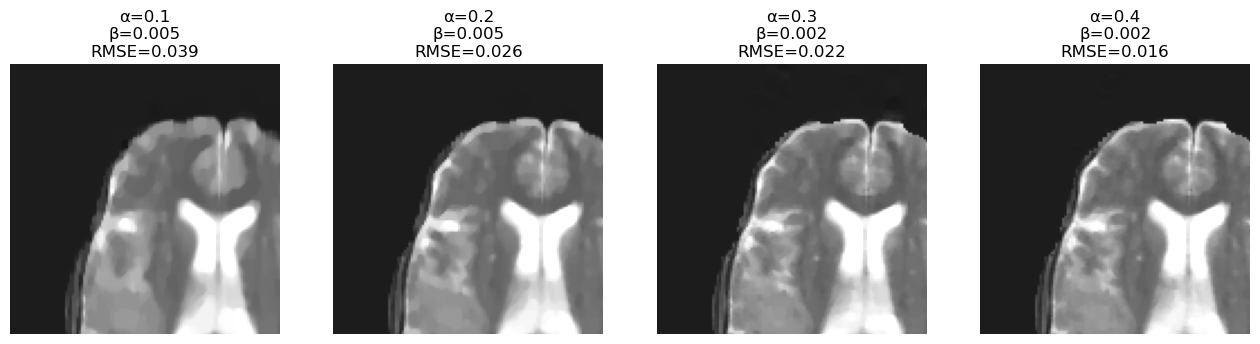

In [159]:
recV = np.array(recV)
recM = recV.reshape(len(subValL), len(betaL), 240, 240)
fig, axs = plt.subplots(1, len(subValL), figsize=(4*len(subValL), 4))
for i, alpha in enumerate(subValL):
    j_best = np.argmin(rmseV[i])
    axs[i].imshow(recM[i, j_best,:,:], cmap='gray',vmax=.8) #,vmin=0.1, vmax=0.9)
    axs[i].set_xlim(30,150)
    axs[i].set_ylim(150,30)
    axs[i].set_title(f"α={alpha}\nβ={betaL[j_best]}\nRMSE={rmseV[i,j_best]:.3f}")
    axs[i].axis('off')

plt.tight_layout()
plt.show()

recV_TV = np.array(recV_TV)
recV_TV = recV_TV.reshape(len(subValL), len(betaL), 240, 240)
fig, axs = plt.subplots(1, len(subValL), figsize=(4*len(subValL), 4))
for i, alpha in enumerate(subValL):
    j_best = np.argmin(rmseTV[i])
    axs[i].imshow(recV_TV[i, j_best,:,:], cmap='gray',vmin=-.1,vmax=.8) #,vmin=0.1, vmax=0.9)
    axs[i].set_xlim(30,150)
    axs[i].set_ylim(150,30)
    axs[i].set_title(f"α={alpha}\nβ={betaL[j_best]}\nRMSE={rmseV[i,j_best]:.3f}")
    axs[i].axis('off')